In [3]:
import numpy as np
import pickle
import matplotlib
import pyfftw
from math import pi as PI
from decimal import Decimal
from matplotlib import cm, rc
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plt
import matplotlib as mpl
import random
mpl.rcParams['text.usetex'] = False  # Disable LaTeX rendering


matplotlib.rc('axes', labelsize=25) 
matplotlib.rc('xtick', labelsize=25) 
matplotlib.rc('ytick', labelsize=25) 
rc('text', usetex=True)



def initc(x, n_points, L):  # Initial condition
 
    u0 = np.zeros_like(x, dtype='longdouble')
    # u0 =  random.random()*np.cos(x/L)*(1.+random.random()*np.sin(x/L)) + random.random()*np.cos(2*x/L)*(1.+random.random()*np.sin(2*x/L)) +  random.random()*np.cos(3*x/L)*(1.+random.random()*np.sin(3*x/L))
    # u0 = random.random()*np.sin(x/L) + random.random()*np.sin(2*x/L) + random.random()*np.sin(3*x/L) 
    # + random.random()*np.sin(4*x/L) + + random.random()*np.sin(5*x/L) + random.random()*np.sin(6*x/L)
    # + random.random()*np.sin(7*x/L) + + random.random()*np.sin(8*x/L) + random.random()*np.sin(9*x/L)
    # + random.random()*np.sin(10*x/L) + + random.random()*np.sin(11*x/L) + random.random()*np.sin(12*x/L)
    
    # x = np.linspace(0, 1, n_points)
    # k = np.fft.rfftfreq(n_points, d=(1.0 / n_points))
    
    # # Define the power spectrum (Gaussian decay)
    # power_spectrum = np.exp(-0.5 * (k * 0.2)**2)
    
    # # Generate random Fourier coefficients
    # random_phases = np.exp(2j * np.pi * np.random.rand(len(k)))
    # fourier_coefficients = np.sqrt(power_spectrum) * random_phases
    
    # # Inverse FFT to obtain the Gaussian random field
    # field = np.fft.irfft(fourier_coefficients, n=n_points)
    N = n_points
    alpha = 2
    tau = 7
    k = np.fft.fftfreq(N, d=L/N) * 2 * np.pi  # Wave numbers
    k[0] = 1e-10  # Avoid division by zero at k=0
    
    # Covariance in Fourier space
    covariance_spectrum = (L**(-2/alpha) * tau**2 / (2*alpha - 1)) * (k**2 + (tau**2 / L**2))**-alpha
    
    # Generate complex Gaussian random variables in Fourier space
    noise_real = np.random.normal(0, np.sqrt(covariance_spectrum / 2), N)
    noise_imag = np.random.normal(0, np.sqrt(covariance_spectrum / 2), N)
    noise = noise_real + 1j * noise_imag
    
    # Ensure reality condition (conjugate symmetry)
    noise[N//2+1:] = np.conj(noise[1:N//2][::-1])
    noise[0] = np.random.normal(0, np.sqrt(covariance_spectrum[0]))  # Ensure real mean zero
    
    # Transform back to physical space
    initial_condition = np.fft.ifft(noise).real
    
    return initial_condition

def wavenum(Mx):  

    kxx = np.fft.rfftfreq(Mx, 1./Mx).astype(float)
    kx = np.zeros_like(kxx, dtype='longdouble')
    kx = kxx/L

    return kx

def fftrtf(uspec):  

    rtf = pyfftw.empty_aligned((Mx,), dtype='clongdouble')
    usp = np.conjugate(uspec[::-1])
    uspect = np.delete(usp, [0,Mx//2], None)
    rtf = np.concatenate((uspec[:], uspect[:]), axis=0)

    return rtf

def weights(x): 

    weights = np.empty_like(x, dtype='longdouble')
    dx = np.empty_like(x, dtype='longdouble')
    nx = len(x)
    for i in range(nx-1):
        dx[i] = x[i+1] - x[i]

    dx = np.delete(dx, [len(x)-1], None)

    for j in range(nx):
        if j == 0:
            weights[j] = dx[0]/2
        elif j == nx-1:
            weights[j] = dx[-1]/2
        else:
            weights[j] = dx[j-1]/2 + dx[j]/2

    return weights

def antialias(uhat,vhat): 

    N = len(uhat)
    M = 2*N
    uhat_pad = np.concatenate((uhat[0:N/2], np.zeros((M-N,)), uhat[N/2:]), axis=0)
    vhat_pad = np.concatenate((vhat[0:N/2], np.zeros((M-N,)), vhat[N/2:]), axis=0)
    u_pad = pyfftw.interfaces.numpy_fft.ifft(uhat_pad)
    v_pad = pyfftw.interfaces.numpy_fft.ifft(vhat_pad)
    w_pad = u_pad*v_pad
    what_pad = pyfftw.interfaces.numpy_fft.fft(w_pad)
    what = 2.*np.concatenate((what_pad[0:N/2], what_pad[M-N/2:M]), axis=0)

    return what

def aalias(uhat):  
    ureal = pyfftw.interfaces.numpy_fft.irfft(uhat)
    nlt = ureal.real*ureal.real
    usp = pyfftw.interfaces.numpy_fft.rfft(nlt)

    return usp

def alias(uht):  
    
    url = pyfftw.interfaces.numpy_fft.ifft(uht)
    nlter = url.real*url.real

    return nlter

def fwnum(Mx):

    alpha = np.fft.fftfreq(Mx, 1./Mx).astype(int)
    alpha[Mx//2] *= -1

    return alpha

def kssol1(u0):  

    Tf = Decimal("150.0")                          					
    t = Decimal("0.0")										
    h = Decimal("0.25")
    dt = float(h)		                         					
    nt = int(Tf/h)  

    kx = wavenum(Mx)    					
    A = np.ones((Mx//2+1,)) 
    k2 = -(kx**2)+(kx**4)      
    u = pyfftw.empty_aligned((Mx//2+1,nt+1), dtype='clongdouble')
    us0 = pyfftw.empty_aligned((Mx//2+1,), dtype='clongdouble')
    u[:,0] = pyfftw.interfaces.numpy_fft.rfft(u0)
    u[0,0] -= u[0,0]
    nlin = pyfftw.empty_aligned((Mx//2+1,nt+1), dtype='clongdouble')
    nlin[:,0] = aalias(u[:,0])
    nlinspec = pyfftw.empty_aligned((Mx//2+1,nt+1), dtype='clongdouble')
    nlinspec[:,0] = -0.5*1j*kx*nlin[:,0]
    nls = pyfftw.empty_aligned((Mx//2+1,), dtype='clongdouble')
    nlspec = pyfftw.empty_aligned((Mx//2+1,), dtype='clongdouble')
    nondx = pyfftw.empty_aligned((Mx,nt+1), dtype='longdouble')
    nondx2 = pyfftw.empty_aligned((Mx,nt+1), dtype='longdouble')
    nondx[:,0] = alias(1j*fwnum(Mx)*fftrtf(u[:,0]))
    nondx2[:,0] = alias(-1.*((fwnum(Mx))**2)*fftrtf(u[:,0]))
    ur = pyfftw.empty_aligned((Mx,nt+1), dtype='longdouble')
    ur[:,0] = pyfftw.interfaces.numpy_fft.irfft(u[:,0]).real
    wt = weights(x)        
    en = np.empty((nt+1,), dtype='longdouble')
    en[0] = np.dot(wt, ur[:,0]*ur[:,0])
    ent = np.empty((nt+1,), dtype='longdouble')
    ent[0] = (2.*np.dot(wt, nondx[:,0]))-(2.*np.dot(wt, nondx2[:,0]))
    
    for i in range(nt):
        t += h
        if i==0:
            us0 = (u[:,i] + (dt*nlinspec[:,i]))/(A + (dt*k2))
            us0[0] -= us0[0]
            us0[-1] -= us0[-1]
            nls[:] = aalias(0.5*(u[:,0]+us0))
            nlspec[:] = -0.5*1j*kx*nls[:]
            u[:,i+1] = (u[:,i] - (0.5*dt*k2*u[:,i]) + (dt*nlspec[:]))/(A + (0.5*dt*k2))
            u[0,i+1] -= u[0,i+1]
            u[-1,i+1] -= u[-1,i+1]
            ur[:,i+1] = pyfftw.interfaces.numpy_fft.irfft(u[:,i+1]).real
            en[i+1] = np.dot(wt, ur[:,i+1]*ur[:,i+1])
            nondx[:,i+1] = alias(1j*fwnum(Mx)*fftrtf(u[:,i+1]))
            nondx2[:,i+1] = alias(-1.*((fwnum(Mx))**2)*fftrtf(u[:,i+1]))
            ent[i+1] = (2.*np.dot(wt, nondx[:,i+1]))-(2.*np.dot(wt, nondx2[:,i+1])) 
        elif i==1:
            nlin[:,i] = aalias(u[:,i])
            nlinspec[:,i] = -0.5*1j*kx*nlin[:,i]
            u[:,i+1] = ((4*u[:,i]) - u[:,i-1] + (4*dt*nlinspec[:,i]) - (2*dt*nlinspec[:,i-1]))/((3*A) + (2*dt*k2))
            u[0,i+1] -= u[0,i+1]
            u[-1,i+1] -= u[-1,i+1]
            ur[:,i+1] = pyfftw.interfaces.numpy_fft.irfft(u[:,i+1]).real
            en[i+1] = np.dot(wt, ur[:,i+1]*ur[:,i+1]) 
            nondx[:,i+1] = alias(1j*fwnum(Mx)*fftrtf(u[:,i+1]))
            nondx2[:,i+1] = alias(-1.*((fwnum(Mx))**2)*fftrtf(u[:,i+1])) 
            ent[i+1] = (2.*np.dot(wt, nondx[:,i+1]))-(2.*np.dot(wt, nondx2[:,i+1]))          
        else:
            nlin[:,i] = aalias(u[:,i])
            nlinspec[:,i] = -0.5*1j*kx*nlin[:,i]
            u[:,i+1] = ((18*u[:,i]) - (9*u[:,i-1]) + (2*u[:,i-2]) + (18*dt*nlinspec[:,i]) - (18*dt*nlinspec[:,i-1]) + (6*dt*nlinspec[:,i-2]))/((11*A) + (6*dt*k2))
            u[0,i+1] -= u[0,i+1]
            u[-1,i+1] -= u[-1,i+1]
            ur[:,i+1] = pyfftw.interfaces.numpy_fft.irfft(u[:,i+1]).real   
            en[i+1] = np.dot(wt, ur[:,i+1]*ur[:,i+1])
            nondx[:,i+1] = alias(1j*fwnum(Mx)*fftrtf(u[:,i+1]))
            nondx2[:,i+1] = alias(-1.*((fwnum(Mx))**2)*fftrtf(u[:,i+1])) 
            ent[i+1] = (2.*np.dot(wt, nondx[:,i+1]))-(2.*np.dot(wt, nondx2[:,i+1]))

    return u, ur, en, ent

# Color plot function
def plot(ax, X, T, f):
    pcm = ax.pcolor(X, T, f, cmap='RdBu')
    plt.colorbar(pcm, ax=ax)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$t$')

def kssol2(u1,u2,u3): 

    Tf = Decimal("150.0")
    h = Decimal("0.25")
    dt = float(h)
    nt = int(Tf/h)

    kx = wavenum(Mx)

    u = pyfftw.empty_aligned((Mx//2+1,nt+3), dtype='clongdouble')
    u[:,0] = u1
    u[:,1] = u2
    u[:,2] = u3
    ur = pyfftw.empty_aligned((Mx,nt+1), dtype='longdouble')
    ur[:,0] = pyfftw.interfaces.numpy_fft.irfft(u[:,2]).real 

    nlin = pyfftw.empty_aligned((Mx//2+1,nt+3), dtype='clongdouble')
    nlin[:,0] = aalias(u[:,0])
    nlin[:,1] = aalias(u[:,1])
    nlin[:,2] = aalias(u[:,2])
    nlinspec = pyfftw.empty_aligned((Mx//2+1,nt+3), dtype='clongdouble')
    nlinspec[:,0] = -0.5*1j*kx*nlin[:,0]
    nlinspec[:,1] = -0.5*1j*kx*nlin[:,1]
    nlinspec[:,2] = -0.5*1j*kx*nlin[:,2]

    nondx = pyfftw.empty_aligned((Mx,nt+1), dtype='longdouble')
    nondx2 = pyfftw.empty_aligned((Mx,nt+1), dtype='longdouble')
    nondx[:,0] = alias(1j*fwnum(Mx)*fftrtf(u[:,2]))
    nondx2[:,0] = alias(-1.*((fwnum(Mx))**2)*fftrtf(u[:,2]))            						
    A = np.ones((Mx//2+1,)) 
    k2 = -(kx**2)+(kx**4)
    k2 += (c*A)        

    wt = weights(x)        
    en = np.empty((nt+1,), dtype='longdouble')
    en[0] = np.dot(wt, ur[:,0]*ur[:,0])
    ent = np.empty((nt+1,), dtype='longdouble')
    ent[0] = (2.*np.dot(wt, nondx[:,0]))-(2.*nu*np.dot(wt, nondx2[:,0]))
    
    for i in range(nt):
        u[:,i+1] = ((18*u[:,i]) - (9*u[:,i-1]) + (2*u[:,i-2]) + (18*dt*nlinspec[:,i]) - (18*dt*nlinspec[:,i-1]) + (6*dt*nlinspec[:,i-2]))/((11*A) + (6*dt*k2))
        u[0,i+3] -= u[0,i+3]
        u[-1,i+3] -= u[-1,i+3]
        ur[:,i+1] = pyfftw.interfaces.numpy_fft.irfft(u[:,i+3]).real
        en[i+1] = np.dot(wt, ur[:,i+1]*ur[:,i+1])
        nlin[:,i+3] = aalias(u[:,i+3])
        nlinspec[:,i+3] = -0.5*1j*kx*nlin[:,i+3]
        nondx[:,i+1] = alias(1j*fwnum(Mx)*fftrtf(u[:,i+3]))
        nondx2[:,i+1] = alias(-1.*((fwnum(Mx))**2)*fftrtf(u[:,i+3])) 
        ent[i+1] = (2.*np.dot(wt, nondx[:,i+1]))-(2.*nu*np.dot(wt, nondx2[:,i+1]))       

    return u, ur, en, ent            									


Mx = 128                  							
L = 24			  
dx = (2.*L*PI)/Mx                 						
x = np.arange(0., Mx)*dx      								
niter = 100
u0_storing = np.zeros([niter, 128, 1 ])	   
ur_storing = np.zeros([niter, 128, 601])
for i in range(niter):
    u0 = initc(x, Mx, L)
    # u0 = u0/np.max(np.abs(u0))*2
    u0_storing[i,:] = u0.reshape(-1, 1)
    u, ur_storing[i,:,:], en, ent = kssol1(u0)

t = np.linspace(0., 150., 601)

np.savez("Kuramoto_Sivashinsky_dataset_sine_initialization_6_random_terms.npz", s_train = ur_storing, u_train = u0_storing)


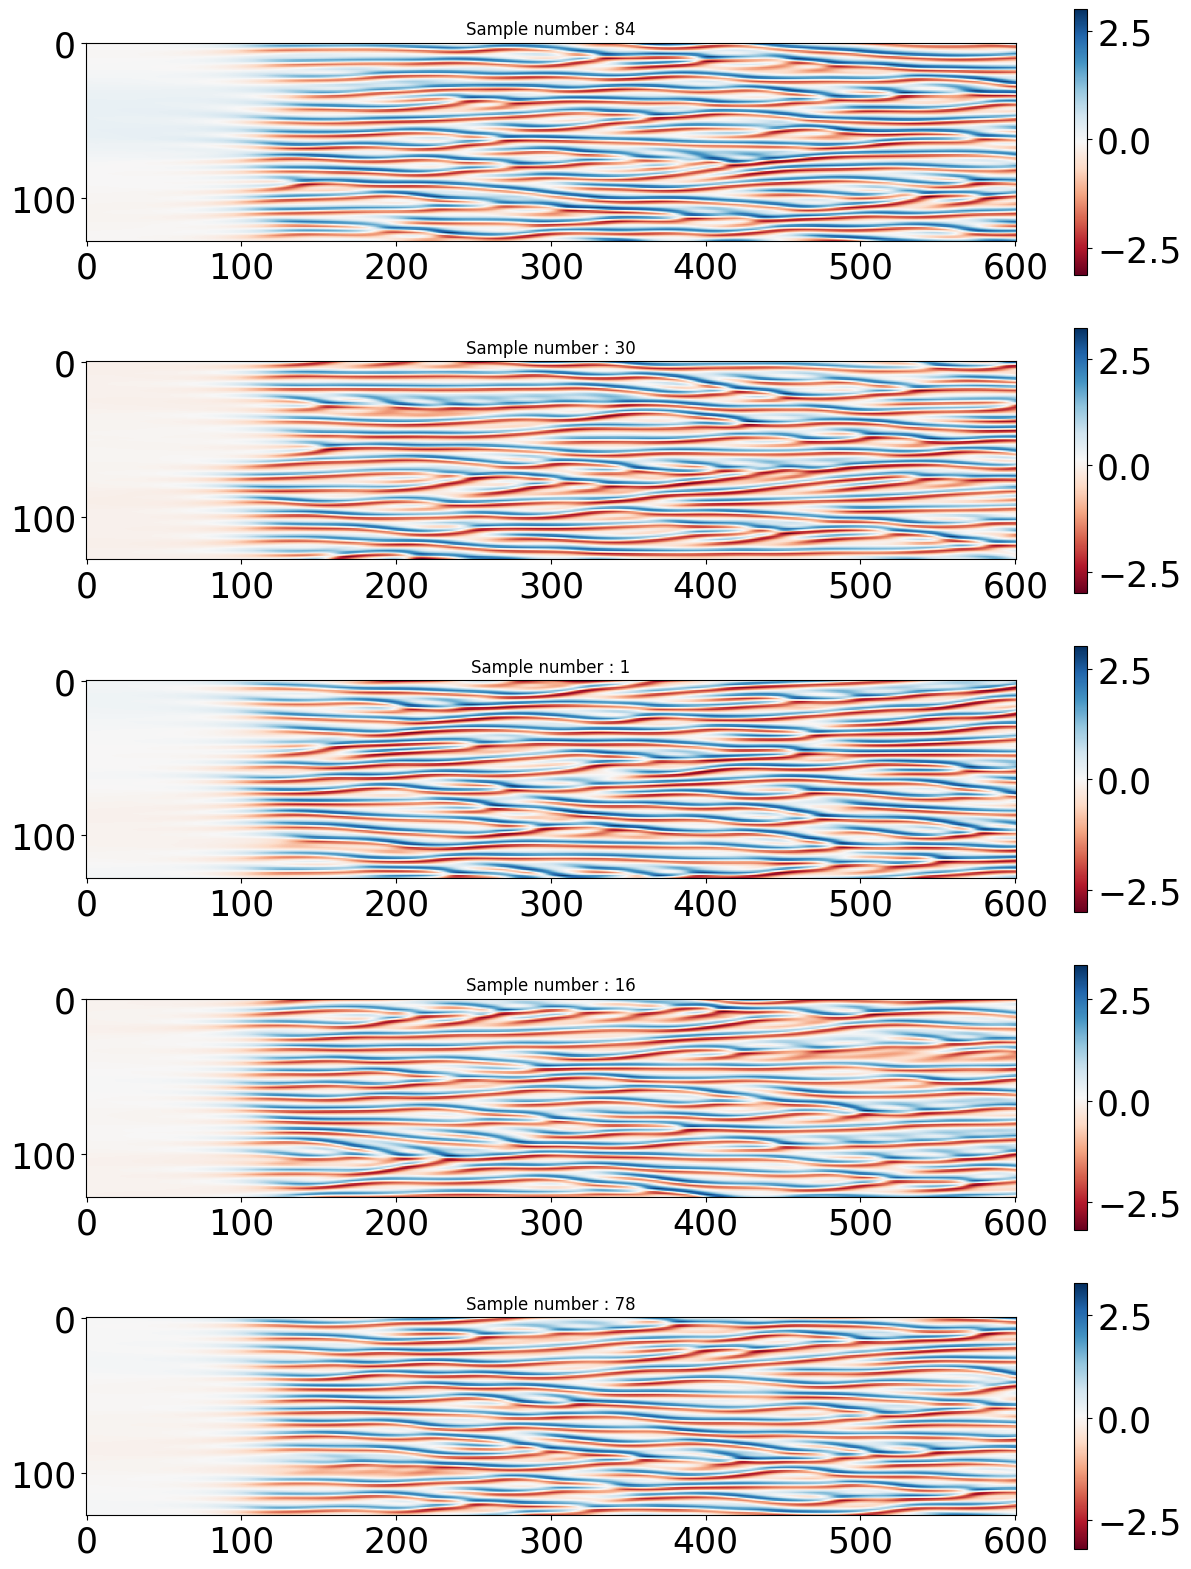

In [6]:
X, T = np.meshgrid(x,t,indexing='ij')
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False  # Disable LaTeX rendering
sample_idx = random.randint(0, ur_storing.shape[0])
sample_idx1 = random.randint(0, ur_storing.shape[0])
sample_idx2 = random.randint(0, ur_storing.shape[0])
sample_idx3 = random.randint(0, ur_storing.shape[0])
sample_idx4 = random.randint(0, ur_storing.shape[0])
fig = plt.figure(figsize=(15,20))
plt.subplot(5,1,1)
plt.imshow(ur_storing[sample_idx,:,:], cmap='RdBu')
plt.title(f'Sample number : {sample_idx}')
plt.colorbar()

plt.subplot(5,1,2)
plt.imshow(ur_storing[sample_idx1,:,:], cmap='RdBu')
plt.title(f'Sample number : {sample_idx1}')
plt.colorbar()

plt.subplot(5,1,3)
plt.imshow(ur_storing[sample_idx2,:,:], cmap='RdBu')
plt.title(f'Sample number : {sample_idx2}')
plt.colorbar()

plt.subplot(5,1,4)
plt.imshow(ur_storing[sample_idx3,:,:], cmap='RdBu')
plt.title(f'Sample number : {sample_idx3}')
plt.colorbar()

plt.subplot(5,1,5)
plt.imshow(ur_storing[sample_idx4,:,:], cmap='RdBu')
plt.title(f'Sample number : {sample_idx4}')
plt.colorbar()

plt.show()